In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
df = pd.read_csv('../data/articles.csv')

print(f"Shape: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nPrimeiras Linhas:")
df.head()

Shape: (167053, 6)

Colunas: ['title', 'text', 'date', 'category', 'subcategory', 'link']

Primeiras Linhas:


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


In [5]:
print("Tipos de dados")
print(df.dtypes)
print(f"\nValores nulos:")
print(df.isnull().sum())
print(f"\nDuplicatas: {df.duplicated().sum()}")

Tipos de dados
title          str
text           str
date           str
category       str
subcategory    str
link           str
dtype: object

Valores nulos:
title               0
text              765
date                0
category            0
subcategory    137418
link                0
dtype: int64

Duplicatas: 0


In [6]:
print("=== VALIDAÇÃO DO DATASET ===")
print(f"\nTotal de notícias: {len(df):,}")
print(f"Período: de {df['date'].min()} até {df['date'].max()}")
print(f"\nCategorias únicas ({df['category'].nunique()}):")
print(df['category'].unique())
print(f"\nSubcategorias únicas: {df['subcategory'].nunique()}")
print(f"\nTamanho médio do título: {df['title'].dropna().apply(len).mean():.0f} caracteres")
print(f"Tamanho médio do texto: {df['text'].dropna().apply(len).mean():.0f} caracteres")

=== VALIDAÇÃO DO DATASET ===

Total de notícias: 167,053
Período: de 2015-01-01 até 2017-10-01

Categorias únicas (48):
<StringArray>
[                       'poder',                    'ilustrada',
                      'mercado',                        'mundo',
                      'esporte',                          'tec',
                    'cotidiano',                     'ambiente',
             'equilibrioesaude',                    'sobretudo',
                      'colunas',                     'educacao',
                           'tv',               'banco-de-dados',
                      'opiniao',                      'ciencia',
               'paineldoleitor',                     'saopaulo',
                 'ilustrissima',              'seminariosfolha',
                      'turismo',           'empreendedorsocial',
                     'serafina',                       'asmais',
        'o-melhor-de-sao-paulo',                          'bbc',
                     

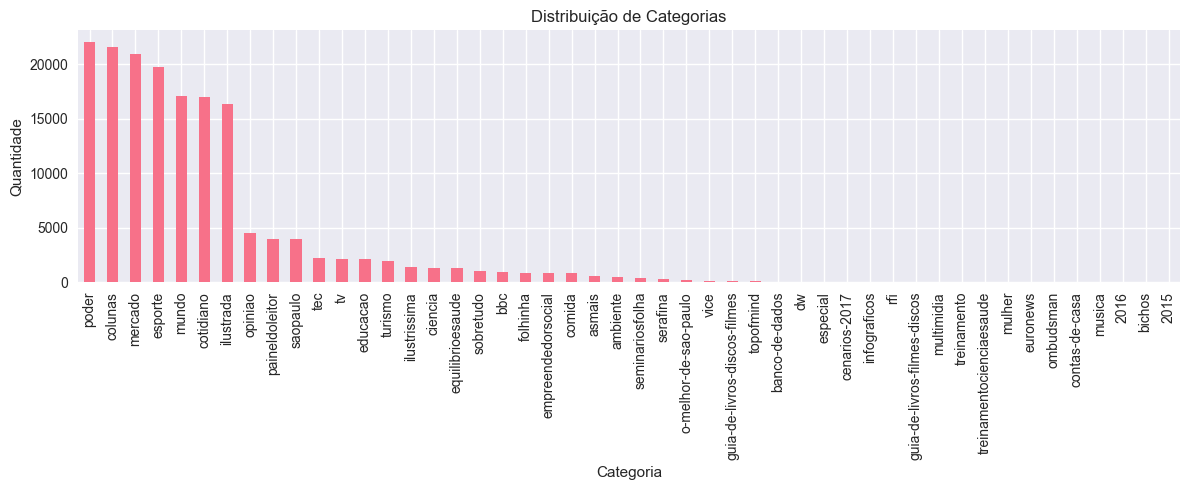

category
poder                           22022
colunas                         21622
mercado                         20970
esporte                         19730
mundo                           17130
cotidiano                       16967
ilustrada                       16345
opiniao                          4525
paineldoleitor                   4011
saopaulo                         3955
tec                              2260
tv                               2142
educacao                         2118
turismo                          1903
ilustrissima                     1411
ciencia                          1335
equilibrioesaude                 1312
sobretudo                        1057
bbc                               980
folhinha                          876
empreendedorsocial                841
comida                            828
asmais                            548
ambiente                          491
seminariosfolha                   379
serafina                          334
o-m

In [9]:
plt.figure(figsize=(12, 5))
df['category'].value_counts().plot(kind='bar')
plt.title('Distribuição de Categorias')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(df['category'].value_counts())

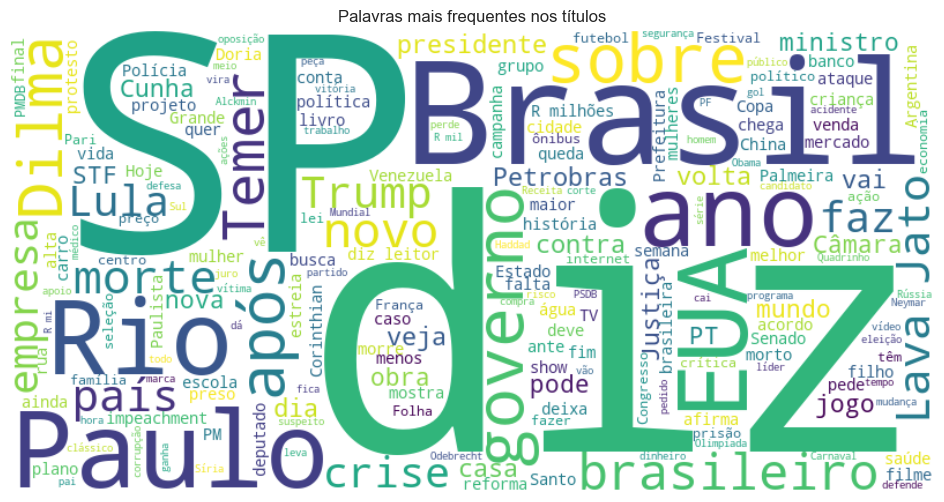

In [10]:
stop_words = set(stopwords.words('portuguese'))

texto = ' '.join(df['title'].dropna().values)

wc = WordCloud(
    width=800,
    height=400,
    stopwords=stop_words,
    background_color='white'
).generate(texto)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras mais frequentes nos títulos')
plt.show()

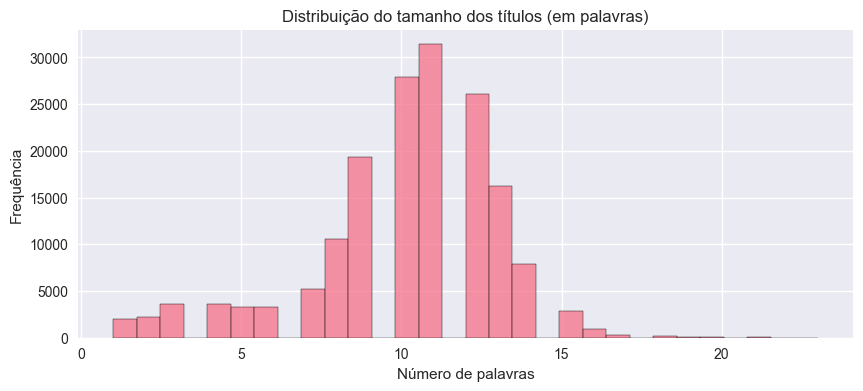

count    167053.000000
mean         10.126517
std           2.897873
min           1.000000
25%           9.000000
50%          11.000000
75%          12.000000
max          23.000000
Name: title_len, dtype: float64


In [11]:
df['title_len'] = df['title'].dropna().apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['title_len'], bins=30)
plt.title('Distribuição do tamanho dos títulos (em palavras)')
plt.xlabel('Número de palavras')
plt.ylabel('Frequência')
plt.show()

print(df['title_len'].describe())